In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./MNRAS.mplstyle')

import os, glob
from pathlib import Path

import h5py

$\delta \ln N_{\rm cyl} = \ln N_{\rm cyl} - \langle\ln N_{\rm cyl} | M \rangle $
where $\langle\ln N_{\rm cyl} | M \rangle$ is obtained by KLLR.

Same for $\delta \ln \Sigma_g$, and so on.

In [2]:
#-------------------- Load correlation data --------------------#

DATA_BASE = Path("corr_scat/")

### ln(Ncyl) -- \Sigma_g ###
# Sigma_g  : d_proj = 300
# Ncyl:
# richness : q_cyl=180
# Mz cut   : -20
# Chi^2 cut: 6
# gal_dens = 1.0e-02
corr_lamsigg = DATA_BASE / "corrcoef_lnlam_sigg_linear_20rps_cyl180_proj300_Mz20_chi26_galdens1.0e-02.h5"
with h5py.File(corr_lamsigg, "r") as f:
    std_corrcoef_lnlam_sigg  = f['std_corrcoef'][:]
    mean_corrcoef_lnlam_sigg = f['mean_corrcoef'][:]
    rp_bins_lamsigg = f['rp_bins'][:]

### ln lambda -- ln Sigma ###
# gal_dens_all   = [1.2e-02, 1.0e-2, 8.0e-3, 6.0e-3, 4.0e-3, 2.0e-3, 1.0e-3]  #, 1.2e-2]
# Mz_cut_all     = [20, 21, 21.5, 22]  ### Mz_cut (4)
# cyl_depth_all  = [30, 60, 90, 120, 180]  # For redmagic cylinder clusters richness (5) @q_cyl
# proj_depth_all = [60, 90, 180, 300] # cMpc/h for lensing measurements (4)   @d_proj
# chi2_cut_all   = [6, 8, 10, 50, 100, 150] ### chi2_cuts (6)

gal_dens  = 1.0e-02
Mz_idx    = 0
qcyl_idx  = 4
dproj_idx = 3
chi2_idx  = 0

corr_lamSig = DATA_BASE / f"corrcoef_lamSigma_20rps_5cyl_4proj_4Mz_6chi2_galdens{gal_dens:.1e}.h5"
print(f"corrcoef_lamSigma_20rps_5cyl_4proj_4Mz_6chi2_galdens{gal_dens:.1e}.h5")
print(20*'-','lnlam-lnSigma',20*'-')

with h5py.File(corr_lamSig, "r") as f:
    err_corrcoef_lamSig  = f['err_corrcoef'][:]
    mean_corrcoef_lamSig = f['mean_corrcoef'][:]
    rp_bins_lamSig = f['rp_bins'][:]
    
    print(gal_dens, "datasets →", list(f.keys()))

### Dimension of err/mean_corrcoef_lamSig: n_rps=20, cyl_depth=5, proj_depth=4, Mz_cuts=4, chi2_cut=6

std_corrcoef_lnlam_lnSig  = err_corrcoef_lamSig [:, qcyl_idx, dproj_idx, Mz_idx, chi2_idx]
mean_corrcoef_lnlam_lnSig = mean_corrcoef_lamSig[:, qcyl_idx, dproj_idx, Mz_idx, chi2_idx]


########################### ln lambda -- ln cy (w/o noise) ############################

corr_lamcy = DATA_BASE / f"corrcoef_lamcy_20rps_5cyl_4proj_4Mz_6chi2_galdens{gal_dens:.1e}.h5"
print(f"corrcoef_lamcy_20rps_5cyl_4proj_4Mz_6chi2_galdens{gal_dens:.1e}.h5")
print(20*'-','lnlam-lncy(w/o noise)',20*'-')
with h5py.File(corr_lamcy, "r") as f:
    err_corrcoef_lamcy  = f['err_corrcoef'][:]
    mean_corrcoef_lamcy = f['mean_corrcoef'][:]
    rp_bins_lamcy = f['rp_bins'][:]
    
std_corrcoef_lnlam_lncy  = err_corrcoef_lamcy [:, qcyl_idx, dproj_idx, Mz_idx, chi2_idx]
mean_corrcoef_lnlam_lncy = mean_corrcoef_lamcy[:, qcyl_idx, dproj_idx, Mz_idx, chi2_idx]

# ########################### ln lambda -- ln cy(SO_baseline_noise) ############################

# corr_lamcy_so_bl = CORR_BASE / f"corrcoef_lnlam_lncy_SO_baseline_dp0_20rps_5cyl_proj300_4Mz_6chi2_galdens{gal_dens:.1e}.h5"
# print(f"corrcoef_lnlam_lncy_SO_baseline_dp0_20rps_5cyl_proj300_4Mz_6chi2_galdens{gal_dens:.1e}.h5")
# print(20*'-','lnlam-lncy (w/ SO baseline noise)',20*'-')
# with h5py.File(corr_lamcy_so_bl, "r") as f:
#     err_corrcoef_lamcy_so_bl  = f['err_corrcoef'][:]
#     mean_corrcoef_lamcy_so_bl = f['mean_corrcoef'][:]
#     rp_bins_lamcy_so_bl = f['rp_bins'][:]
    
# std_corrcoef_lnlam_ln_nscy  = err_corrcoef_lamcy_so_bl [:, qcyl_idx, Mz_idx, chi2_idx]
# mean_corrcoef_lnlam_ln_nscy = mean_corrcoef_lamcy_so_bl[:, qcyl_idx, Mz_idx, chi2_idx]


corrcoef_lamSigma_20rps_5cyl_4proj_4Mz_6chi2_galdens1.0e-02.h5
-------------------- lnlam-lnSigma --------------------
0.01 datasets → ['err_corrcoef', 'mean_corrcoef', 'rp_bins']
corrcoef_lamcy_20rps_5cyl_4proj_4Mz_6chi2_galdens1.0e-02.h5
-------------------- lnlam-lncy(w/o noise) --------------------


In [3]:
def load_scatter_hdf5(infile):
    """
    Load scatter-vs-rp results and metadata from an HDF5 file.

    Returns
    -------
    data : dict
        Nested dictionary with keys:
        - 'rp_bins'
        - 'meta'
        - 'scatter'
    """
    data = {
        "rp_bins": None,
        "meta": {},
        "scatter": {}
    }

    with h5py.File(infile, "r") as h5:
        # rp
        data["rp_bins"] = h5["rp_bins"][:]

        # meta attrs
        if "meta" in h5:
            meta = h5["meta"]

            for key, val in meta.attrs.items():
                data["meta"][key] = val

            for key in meta.keys():
                arr = meta[key][:]
                if arr.dtype.kind == "S":
                    arr = arr.astype(str)
                data["meta"][key] = arr

        # scatter groups
        if "scatter" in h5:
            scat = h5["scatter"]

            for obs_name in scat.keys():
                g = scat[obs_name]

                data["scatter"][obs_name] = {
                    "mean": g["mean"][:],
                    "err": g["err"][:],
                    "attrs": dict(g.attrs)
                }

    return data


scatfile = DATA_BASE / "scatter_kllr_rpresid_20rps_7ng_5qproj_proj300_add_sigg.h5"


dat = load_scatter_hdf5(scatfile)

rp = dat["rp_bins"]
ng = dat["meta"]["gal_dens_num"]
qproj = dat["meta"]["cyl_depth"]

# scat_DS_mean = dat["scatter"]["DeltaSigma"]["mean"]
# scat_DS_err  = dat["scatter"]["DeltaSigma"]["err"]

scat_lnSig_mean = dat["scatter"]["lnSigma"]["mean"]  ### mean of residual
scat_lnSig_err  = dat["scatter"]["lnSigma"]["err"]   ###  std of residual

scat_lny_mean = dat["scatter"]["lnycyl"]["mean"]
scat_lny_err  = dat["scatter"]["lnycyl"]["err"]


# scat_lny_so_bl_mean = dat["scatter"]["lnycyl_so_baseline"]["mean"]
# scat_lny_so_bl_err  = dat["scatter"]["lnycyl_so_baseline"]["err"]

scat_sigg_hd_mean = dat["scatter"]["sigg_hd"]["mean"]
scat_sigg_hd_err = dat["scatter"]["sigg_hd"]["err"]

print("rp shape:", rp.shape)
print("cy_true mean shape:", scat_lny_mean.shape)
print("lnSigma mean shape:", scat_lnSig_mean.shape)
print("sigg_hd mean shape:", scat_sigg_hd_mean.shape)
print("gal_dens_num:", ng)
print("cyl_depth:", qproj)

rp shape: (20,)
cy_true mean shape: (20, 7, 5)
lnSigma mean shape: (20, 7, 5)
sigg_hd mean shape: (20, 7, 5)
gal_dens_num: [0.012 0.01  0.008 0.006 0.004 0.002 0.001]
cyl_depth: [ 30.  60.  90. 120. 180.]


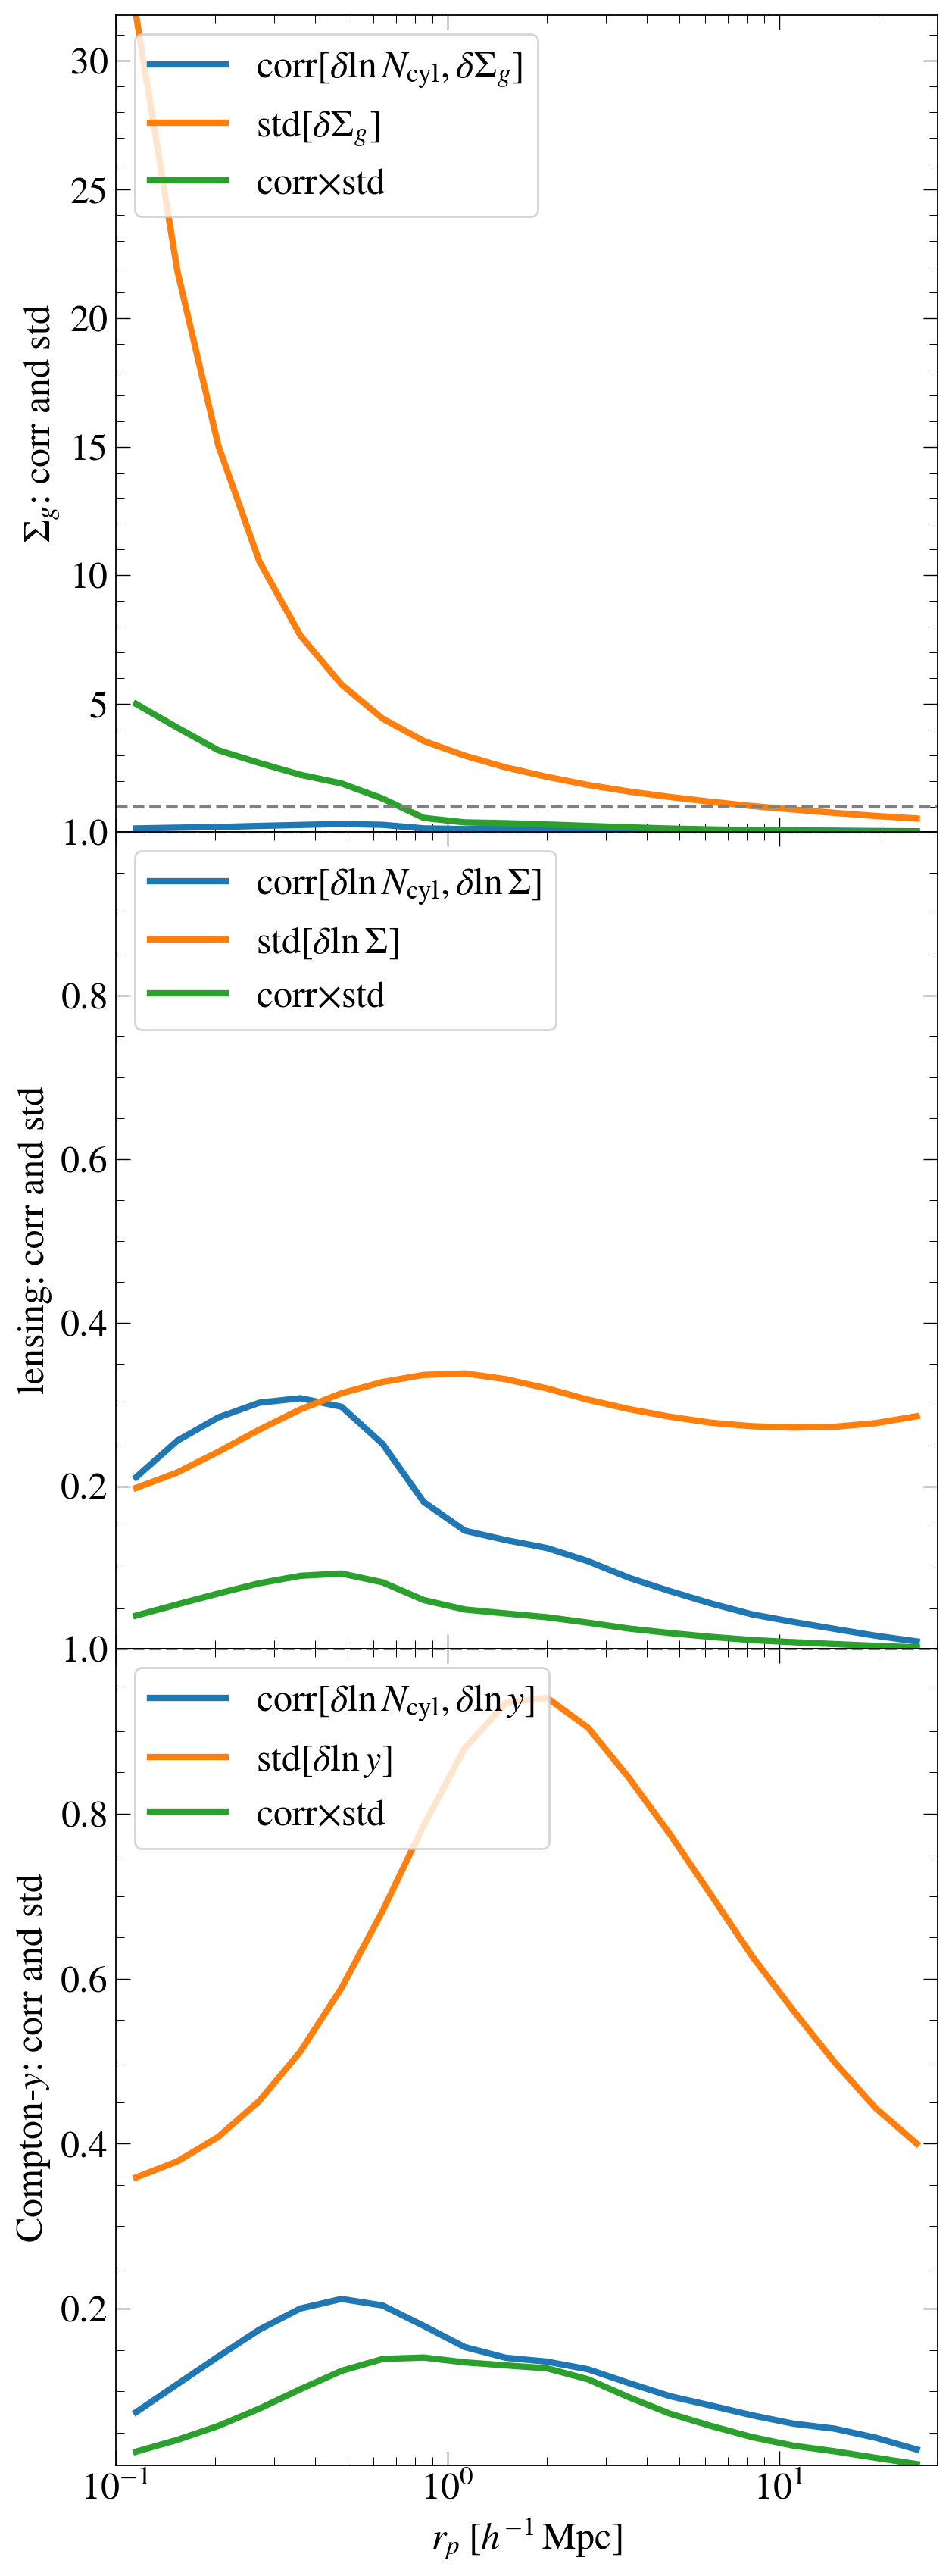

In [4]:
### use all the halos you have, without binning

fig, axes = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(7, 21),
    gridspec_kw={'hspace': 0}
)

row_ylabels = [
    r"$\Sigma_g$: corr and std",
    r"lensing: corr and std",
    r"Compton-$y$: corr and std",
]


for row, ylabel in enumerate(row_ylabels):
    axes[row].set_ylabel(ylabel)

for col in range(4):
    axes[2].set_xlabel(r"$r_p \; [h^{-1}\,\mathrm{Mpc}]$")


qcyl_sct = 4
gd_sct   = 1
for row in range(3):


    ax = axes[row]
    if row == 0:  # galaxy distribution
        
        ### TODO: placeholder
        rp = rp_bins_lamsigg                #np.geomspace(0.1, 30)
        corr = mean_corrcoef_lnlam_sigg     #0.2*rp+1 
        corr_err = std_corrcoef_lnlam_sigg #0.05
        
        scatt = scat_sigg_hd_mean[:, gd_sct, qcyl_sct] #0.4*rp+1 
        scatt_err = scat_sigg_hd_err[:, gd_sct, qcyl_sct]

        corr_scatt_err = np.sqrt((corr_err/corr)**2 + (scatt_err/scatt)**2) # error propagation formula
        
        # line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln N_{\rm cyl} , \delta\ln\Sigma_g]$")
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln N_{\rm cyl} , \delta \Sigma_g]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        # line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln\Sigma_g]$")
        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\Sigma_g]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        
    if row == 1:  # lensing
        ## TODO: same for lensing with d=300
        rp = rp_bins_lamSig                #np.geomspace(0.1, 30)
        corr = mean_corrcoef_lnlam_lnSig     #0.2*rp+1 
        corr_err = std_corrcoef_lnlam_lnSig #0.05
        
        scatt = scat_lnSig_mean[:, gd_sct, qcyl_sct] #0.4*rp+1 
        scatt_err = scat_lnSig_err[:, gd_sct, qcyl_sct]

        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln N_{\rm cyl} , \delta\ln\Sigma]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln\Sigma]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    if row == 2:  # SZ            
        ## TODO: same for y with d=300 (no noise)
        rp = rp_bins_lamcy                #np.geomspace(0.1, 30)
        corr = mean_corrcoef_lnlam_lncy     #0.2*rp+1 
        corr_err = std_corrcoef_lnlam_lncy #0.05
        
        scatt = scat_lny_mean[:, gd_sct, qcyl_sct] #0.4*rp+1 
        scatt_err = scat_lny_err[:, gd_sct, qcyl_sct]
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln N_{\rm cyl} , \delta\ln y]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln y]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    ax.axhline(1, c='gray', ls='--')
    # ax.set_ylim(0.9, 1.5)
    ax.set_xlim(0.1, 30)
    ax.set_xscale('log')        
    
    ax.legend(loc=2)
    ax.grid(False)
# plt.savefig('../plots/richness_correlation.pdf')

# Note: Only $\Sigma_g$ is changed to  $\ln \Sigma_g$ in the figure

In [5]:
corr_lnlamlnsigg = DATA_BASE / "corrcoef_lnlam_lnsigg_spearman_20rps_cyl180_proj300_Mz20_chi26_galdens1.0e-02.h5"
# Use the Spearman rank correlation instead of Pearson correlation.
# N halos       : 73325
# sigg floor    : set zeros to 1e-06
with h5py.File(corr_lnlamlnsigg, "r") as f:
    std_corrcoef_lnlam_lnsigg  = f['std_corrcoef'][:]
    mean_corrcoef_lnlam_lnsigg = f['mean_corrcoef'][:]
    rp_bins_lnlam_lnsigg = f['rp_bins'][:]


scatfile = DATA_BASE / "scatter_kllr_rpresid_20rps_7ng_5qproj_proj300_add_lnsigg.h5"
dat = load_scatter_hdf5(scatfile)

scat_lnsigg_hd_mean = dat["scatter"]["sigg_hd"]["mean"][:]
scat_lnsigg_hd_err  = dat["scatter"]["sigg_hd"]["err"][:]
print("scat_lnsigg_hd_mean.shape", scat_lnsigg_hd_mean.shape)

scat_lnsigg_hd_mean.shape (20, 7, 5)


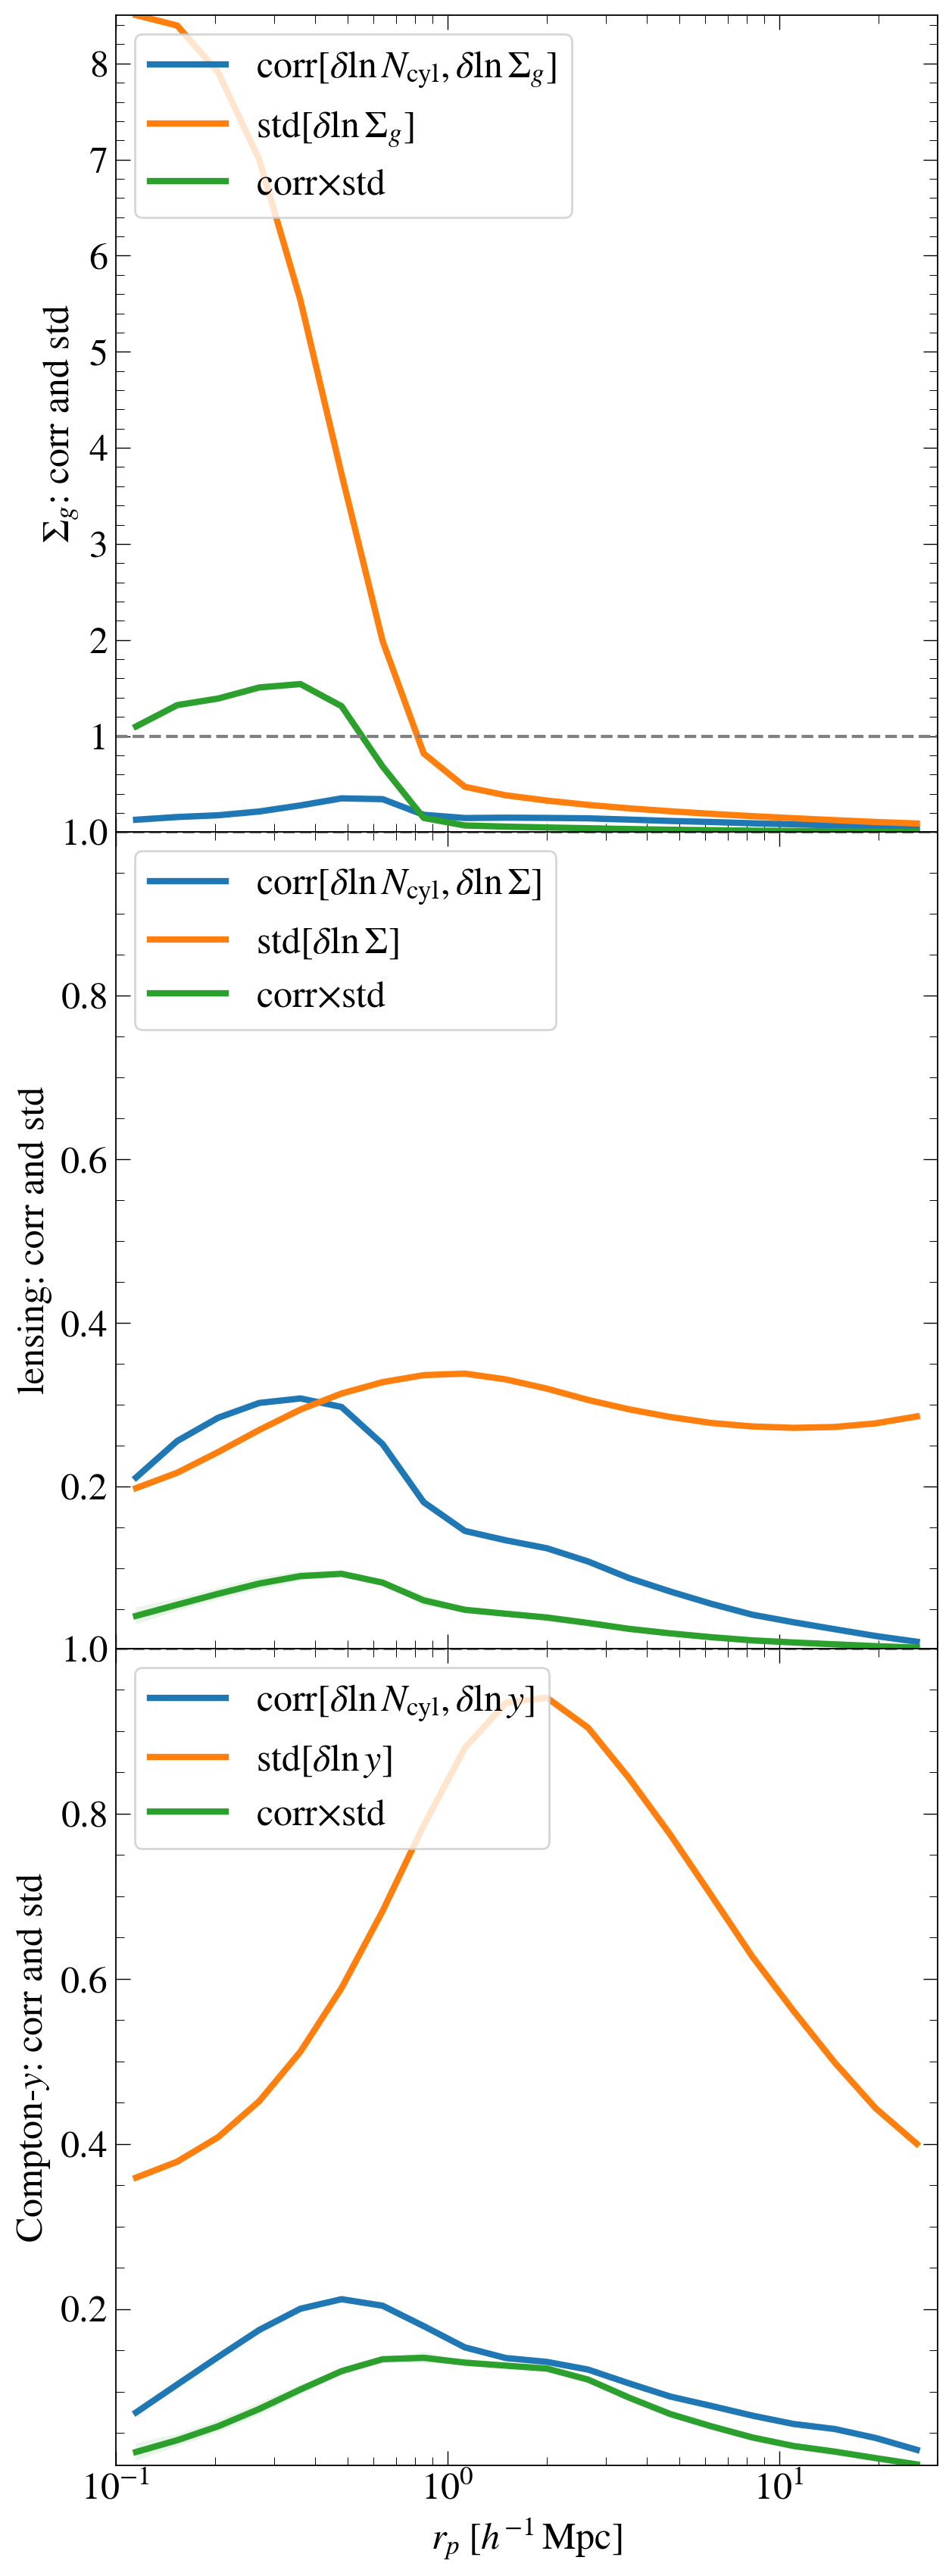

In [6]:
### use all the halos you have, without binning

fig, axes = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(7, 21),
    gridspec_kw={'hspace': 0}
)

row_ylabels = [
    r"$\Sigma_g$: corr and std",
    r"lensing: corr and std",
    r"Compton-$y$: corr and std",
]


for row, ylabel in enumerate(row_ylabels):
    axes[row].set_ylabel(ylabel)

for col in range(4):
    axes[2].set_xlabel(r"$r_p \; [h^{-1}\,\mathrm{Mpc}]$")


qcyl_sct = 4
gd_sct   = 1
for row in range(3):


    ax = axes[row]
    if row == 0:  # galaxy distribution
        
        ### TODO: placeholder
        rp = rp_bins_lnlam_lnsigg                #np.geomspace(0.1, 30)
        corr = mean_corrcoef_lnlam_lnsigg     #0.2*rp+1 
        corr_err = std_corrcoef_lnlam_lnsigg #0.05
        
        scatt = scat_lnsigg_hd_mean[:, gd_sct, qcyl_sct] #0.4*rp+1 
        scatt_err = scat_lnsigg_hd_err[:, gd_sct, qcyl_sct]

        corr_scatt_err = np.sqrt((corr_err/corr)**2 + (scatt_err/scatt)**2) # error propagation formula
        
        # line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln N_{\rm cyl} , \delta\ln\Sigma_g]$")
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln N_{\rm cyl} , \delta \ln \Sigma_g]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        # line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln\Sigma_g]$")
        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta \ln \Sigma_g]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        
    if row == 1:  # lensing
        ## TODO: same for lensing with d=300
        rp = rp_bins_lamSig                #np.geomspace(0.1, 30)
        corr = mean_corrcoef_lnlam_lnSig     #0.2*rp+1 
        corr_err = std_corrcoef_lnlam_lnSig #0.05
        
        scatt = scat_lnSig_mean[:, gd_sct, qcyl_sct] #0.4*rp+1 
        scatt_err = scat_lnSig_err[:, gd_sct, qcyl_sct]

        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln N_{\rm cyl} , \delta\ln\Sigma]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln\Sigma]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    if row == 2:  # SZ            
        ## TODO: same for y with d=300 (no noise)
        rp = rp_bins_lamcy                #np.geomspace(0.1, 30)
        corr = mean_corrcoef_lnlam_lncy     #0.2*rp+1 
        corr_err = std_corrcoef_lnlam_lncy #0.05
        
        scatt = scat_lny_mean[:, gd_sct, qcyl_sct] #0.4*rp+1 
        scatt_err = scat_lny_err[:, gd_sct, qcyl_sct]
        
        line = ax.plot(rp, corr, lw=3, label=r"corr$[\delta\ln N_{\rm cyl} , \delta\ln y]$")
        ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        line = ax.plot(rp, scatt, lw=3, label=r"std$[\delta\ln y]$")
        ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
        line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
        ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

    
    ax.axhline(1, c='gray', ls='--')
    # ax.set_ylim(0.9, 1.5)
    ax.set_xlim(0.1, 30)
    ax.set_xscale('log')        
    
    ax.legend(loc=2)
    ax.grid(False)
# plt.savefig('../plots/richness_correlation.pdf')